In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.io import imread
from sklearn import svm, tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [15]:
# ====================
# CONFIGURATION
# ====================
os.chdir('D:\\UNI\\ZNU\\Term 1\\Pattern Recognition\\EXE\\saem project\\ex1\\Step 1\\data')



Processing: MS (4 Bands)

Processing: MS + NDVI

Processing: MS + NDVI + Texture


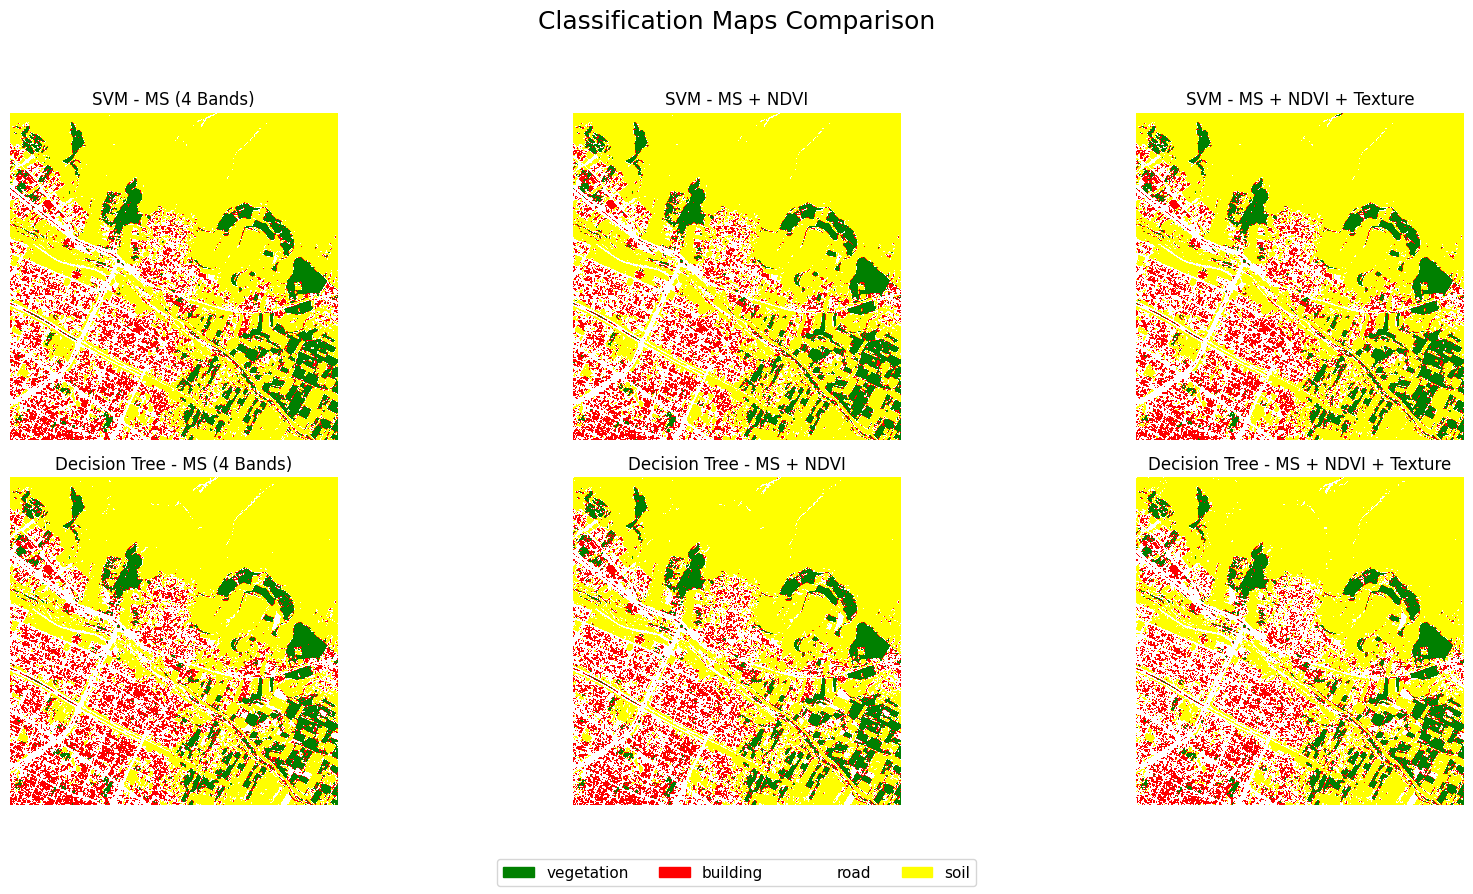

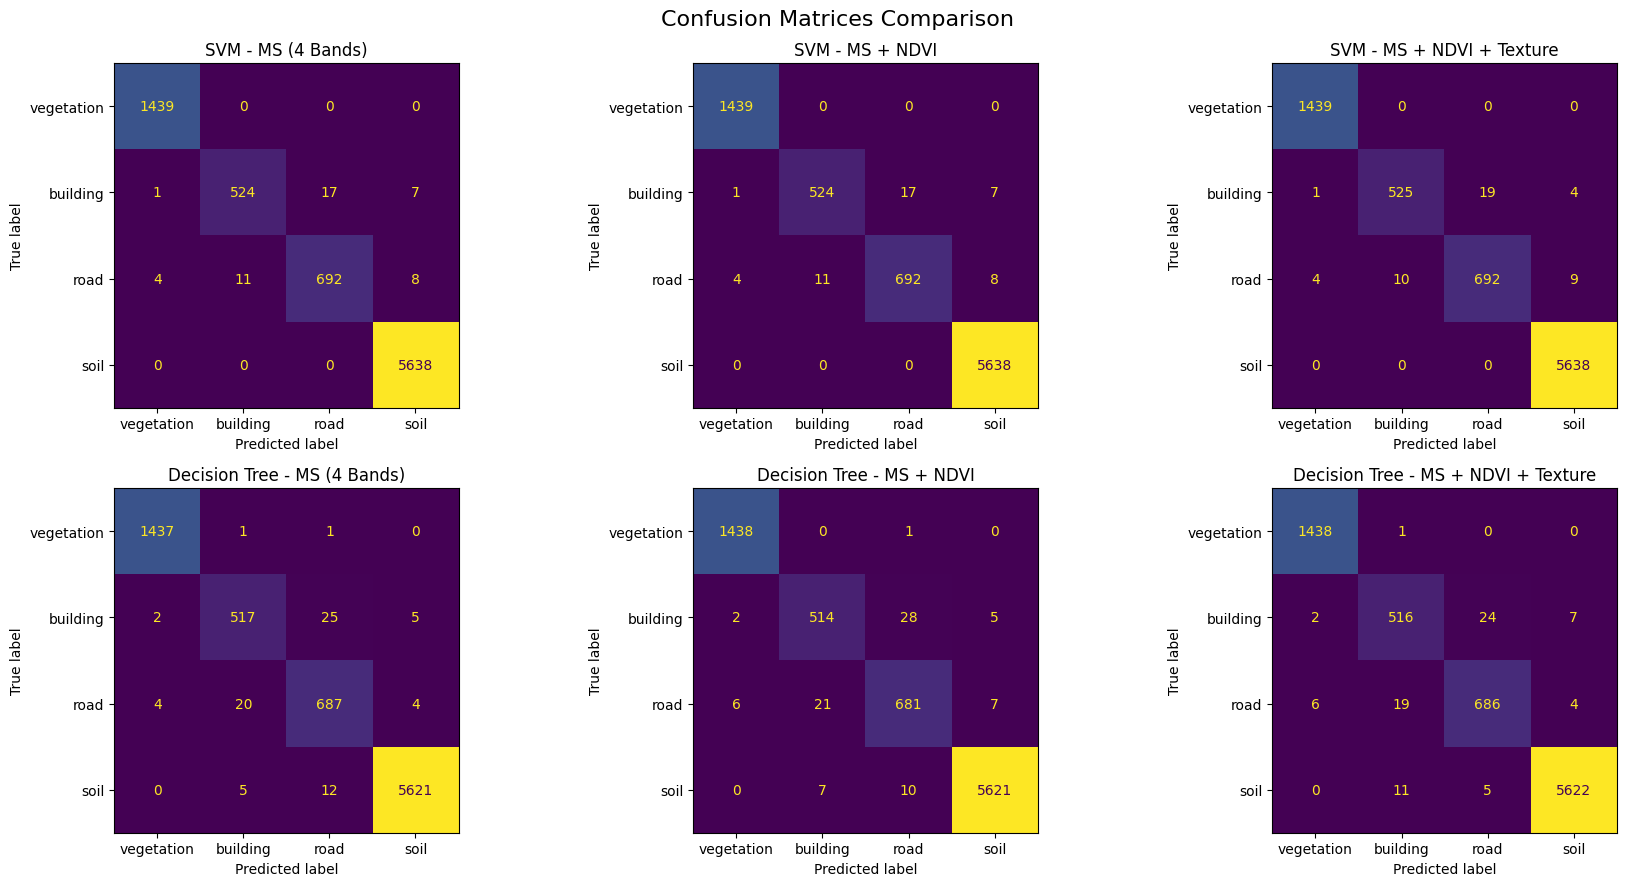


================ BEST RESULTS ================
Best SVM: MS + NDVI + Texture  →  99.44%
Best Decision Tree: MS (4 Bands)  →  99.05%


In [16]:
# ====================
# NORMALIZATION
# ====================
def normalize(img):
    img = img.astype(np.float32)
    img_min = np.min(img, axis=(0, 1), keepdims=True)
    img_max = np.max(img, axis=(0, 1), keepdims=True)
    return (img - img_min) / (img_max - img_min + 1e-8)

# ====================
# DATA PREPARATION
# ====================
def prepare_data(image_path, roi_path):
    ms = imread(image_path)
    labels = imread(roi_path)

    if len(ms.shape) == 3 and ms.shape[0] < ms.shape[1]:
        ms = np.transpose(ms, (1, 2, 0))

    row, col, band = ms.shape

    if labels.shape != (row, col):
        raise ValueError("ابعاد تصویر و ROI یکسان نیست")

    ms_n = normalize(ms)
    ms_flat = ms_n.reshape(-1, band)
    labels_flat = labels.reshape(-1)

    mask = labels_flat != 0
    X = ms_flat[mask]
    y = labels_flat[mask]

    return X, y, ms_flat, row, col

# ====================
# TRAIN & EVALUATE
# ====================
def train_evaluate(X, y, ms_flat, row, col, model):
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    model.fit(x_train, y_train)

    y_pred_test = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred_test)

    class_acc = cm.diagonal() / cm.sum(axis=1) * 100
    overall_acc = np.sum(cm.diagonal()) / np.sum(cm) * 100

    y_pred_full = model.predict(ms_flat)
    classified_map = y_pred_full.reshape(row, col)

    return cm, class_acc, overall_acc, classified_map

# ====================
# FILE PATHS
# ====================
images = {
    "MS (4 Bands)": r"D:\UNI\ZNU\Term 1\Pattern Recognition\EXE\saem project\ex1\Step 1\data\BGRNIR.tif",
    "MS + NDVI": r"D:\UNI\ZNU\Term 1\Pattern Recognition\EXE\saem project\ex1\Step 1\data\BGRNIRNDVI.tif",
    "MS + NDVI + Texture": r"D:\UNI\ZNU\Term 1\Pattern Recognition\EXE\saem project\ex1\Step 1\data\BGR NIR + NDVI + VARIANCE.tif"
}

roi_path = r"D:\UNI\ZNU\Term 1\Pattern Recognition\EXE\saem project\ex1\Step 1\data\rois.tif"

# ====================
# VISUALIZATION SETUP
# ====================
colors = ['green', 'red', 'white', 'yellow']
class_names = ['vegetation', 'building', 'road', 'soil']
cmap = ListedColormap(colors)
legend_patches = [Patch(color=c, label=l) for c, l in zip(colors, class_names)]

# ====================
# MAIN PROCESS
# ====================
svm_maps = {}
dt_maps = {}
svm_cms = {}
dt_cms = {}
accuracy_table = []

for name, path in images.items():
    print(f"\nProcessing: {name}")

    X, y, ms_flat, row, col = prepare_data(path, roi_path)

    # --- SVM ---
    svm_model = svm.SVC(C=30, kernel='linear', gamma=13)
    svm_cm, svm_class_acc, svm_oa, svm_map = train_evaluate(
        X, y, ms_flat, row, col, svm_model
    )

    # --- Decision Tree ---
    dt_model = tree.DecisionTreeClassifier(random_state=42)
    dt_cm, dt_class_acc, dt_oa, dt_map = train_evaluate(
        X, y, ms_flat, row, col, dt_model
    )

    svm_maps[name] = svm_map
    dt_maps[name] = dt_map
    svm_cms[name] = svm_cm
    dt_cms[name] = dt_cm

    accuracy_table.append([name, "SVM", svm_oa])
    accuracy_table.append([name, "Decision Tree", dt_oa])

# ====================
# SUBPLOT: CLASSIFICATION MAPS (WITH LEGEND)
# ====================
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

i = 0
for name in images.keys():
    axes[i].imshow(svm_maps[name], cmap=cmap)
    axes[i].set_title(f"SVM - {name}")
    axes[i].axis('off')
    i += 1

for name in images.keys():
    axes[i].imshow(dt_maps[name], cmap=cmap)
    axes[i].set_title(f"Decision Tree - {name}")
    axes[i].axis('off')
    i += 1

# Legend مشترک
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=len(class_names),
    fontsize=11,
    frameon=True
)

fig.suptitle("Classification Maps Comparison", fontsize=18)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

# ====================
# SUBPLOT: CONFUSION MATRICES
# ====================
plt.figure(figsize=(18, 9))
i = 1

for name in images.keys():
    plt.subplot(2, 3, i)
    ConfusionMatrixDisplay(
        svm_cms[name],
        display_labels=class_names
    ).plot(ax=plt.gca(), colorbar=False)
    plt.title(f"SVM - {name}")
    i += 1

for name in images.keys():
    plt.subplot(2, 3, i)
    ConfusionMatrixDisplay(
        dt_cms[name],
        display_labels=class_names
    ).plot(ax=plt.gca(), colorbar=False)
    plt.title(f"Decision Tree - {name}")
    i += 1

plt.suptitle("Confusion Matrices Comparison", fontsize=16)
plt.tight_layout()
plt.show()

# ====================
# BEST RESULT REPORT
# ====================
df_acc = pd.DataFrame(
    accuracy_table,
    columns=["Image", "Classifier", "Overall Accuracy (%)"]
)

best_svm = df_acc[df_acc["Classifier"] == "SVM"] \
    .sort_values("Overall Accuracy (%)", ascending=False).iloc[0]

best_dt = df_acc[df_acc["Classifier"] == "Decision Tree"] \
    .sort_values("Overall Accuracy (%)", ascending=False).iloc[0]

print("\n================ BEST RESULTS ================")
print(f"Best SVM: {best_svm['Image']}  →  {best_svm['Overall Accuracy (%)']:.2f}%")
print(f"Best Decision Tree: {best_dt['Image']}  →  {best_dt['Overall Accuracy (%)']:.2f}%")
print("============================================")



Training Batch 1 - SVM 1: kernel=linear, C=1, gamma=scale, degree=3

Training Batch 1 - SVM 2: kernel=rbf, C=5, gamma=0.1, degree=3

Training Batch 1 - SVM 3: kernel=poly, C=10, gamma=0.5, degree=2

Training Batch 1 - SVM 4: kernel=sigmoid, C=15, gamma=0.3, degree=3

Training Batch 2 - SVM 1: kernel=linear, C=10, gamma=scale, degree=3

Training Batch 2 - SVM 2: kernel=rbf, C=10, gamma=1, degree=3

Training Batch 2 - SVM 3: kernel=poly, C=20, gamma=1, degree=3

Training Batch 2 - SVM 4: kernel=sigmoid, C=20, gamma=1, degree=3

Training Batch 3 - SVM 1: kernel=linear, C=30, gamma=scale, degree=3

Training Batch 3 - SVM 2: kernel=rbf, C=30, gamma=5, degree=3

Training Batch 3 - SVM 3: kernel=poly, C=30, gamma=5, degree=3

Training Batch 3 - SVM 4: kernel=sigmoid, C=30, gamma=5, degree=3

Training Batch 4 - SVM 1: kernel=linear, C=50, gamma=scale, degree=3

Training Batch 4 - SVM 2: kernel=rbf, C=50, gamma=20, degree=3

Training Batch 4 - SVM 3: kernel=poly, C=50, gamma=20, degree=4

Trai

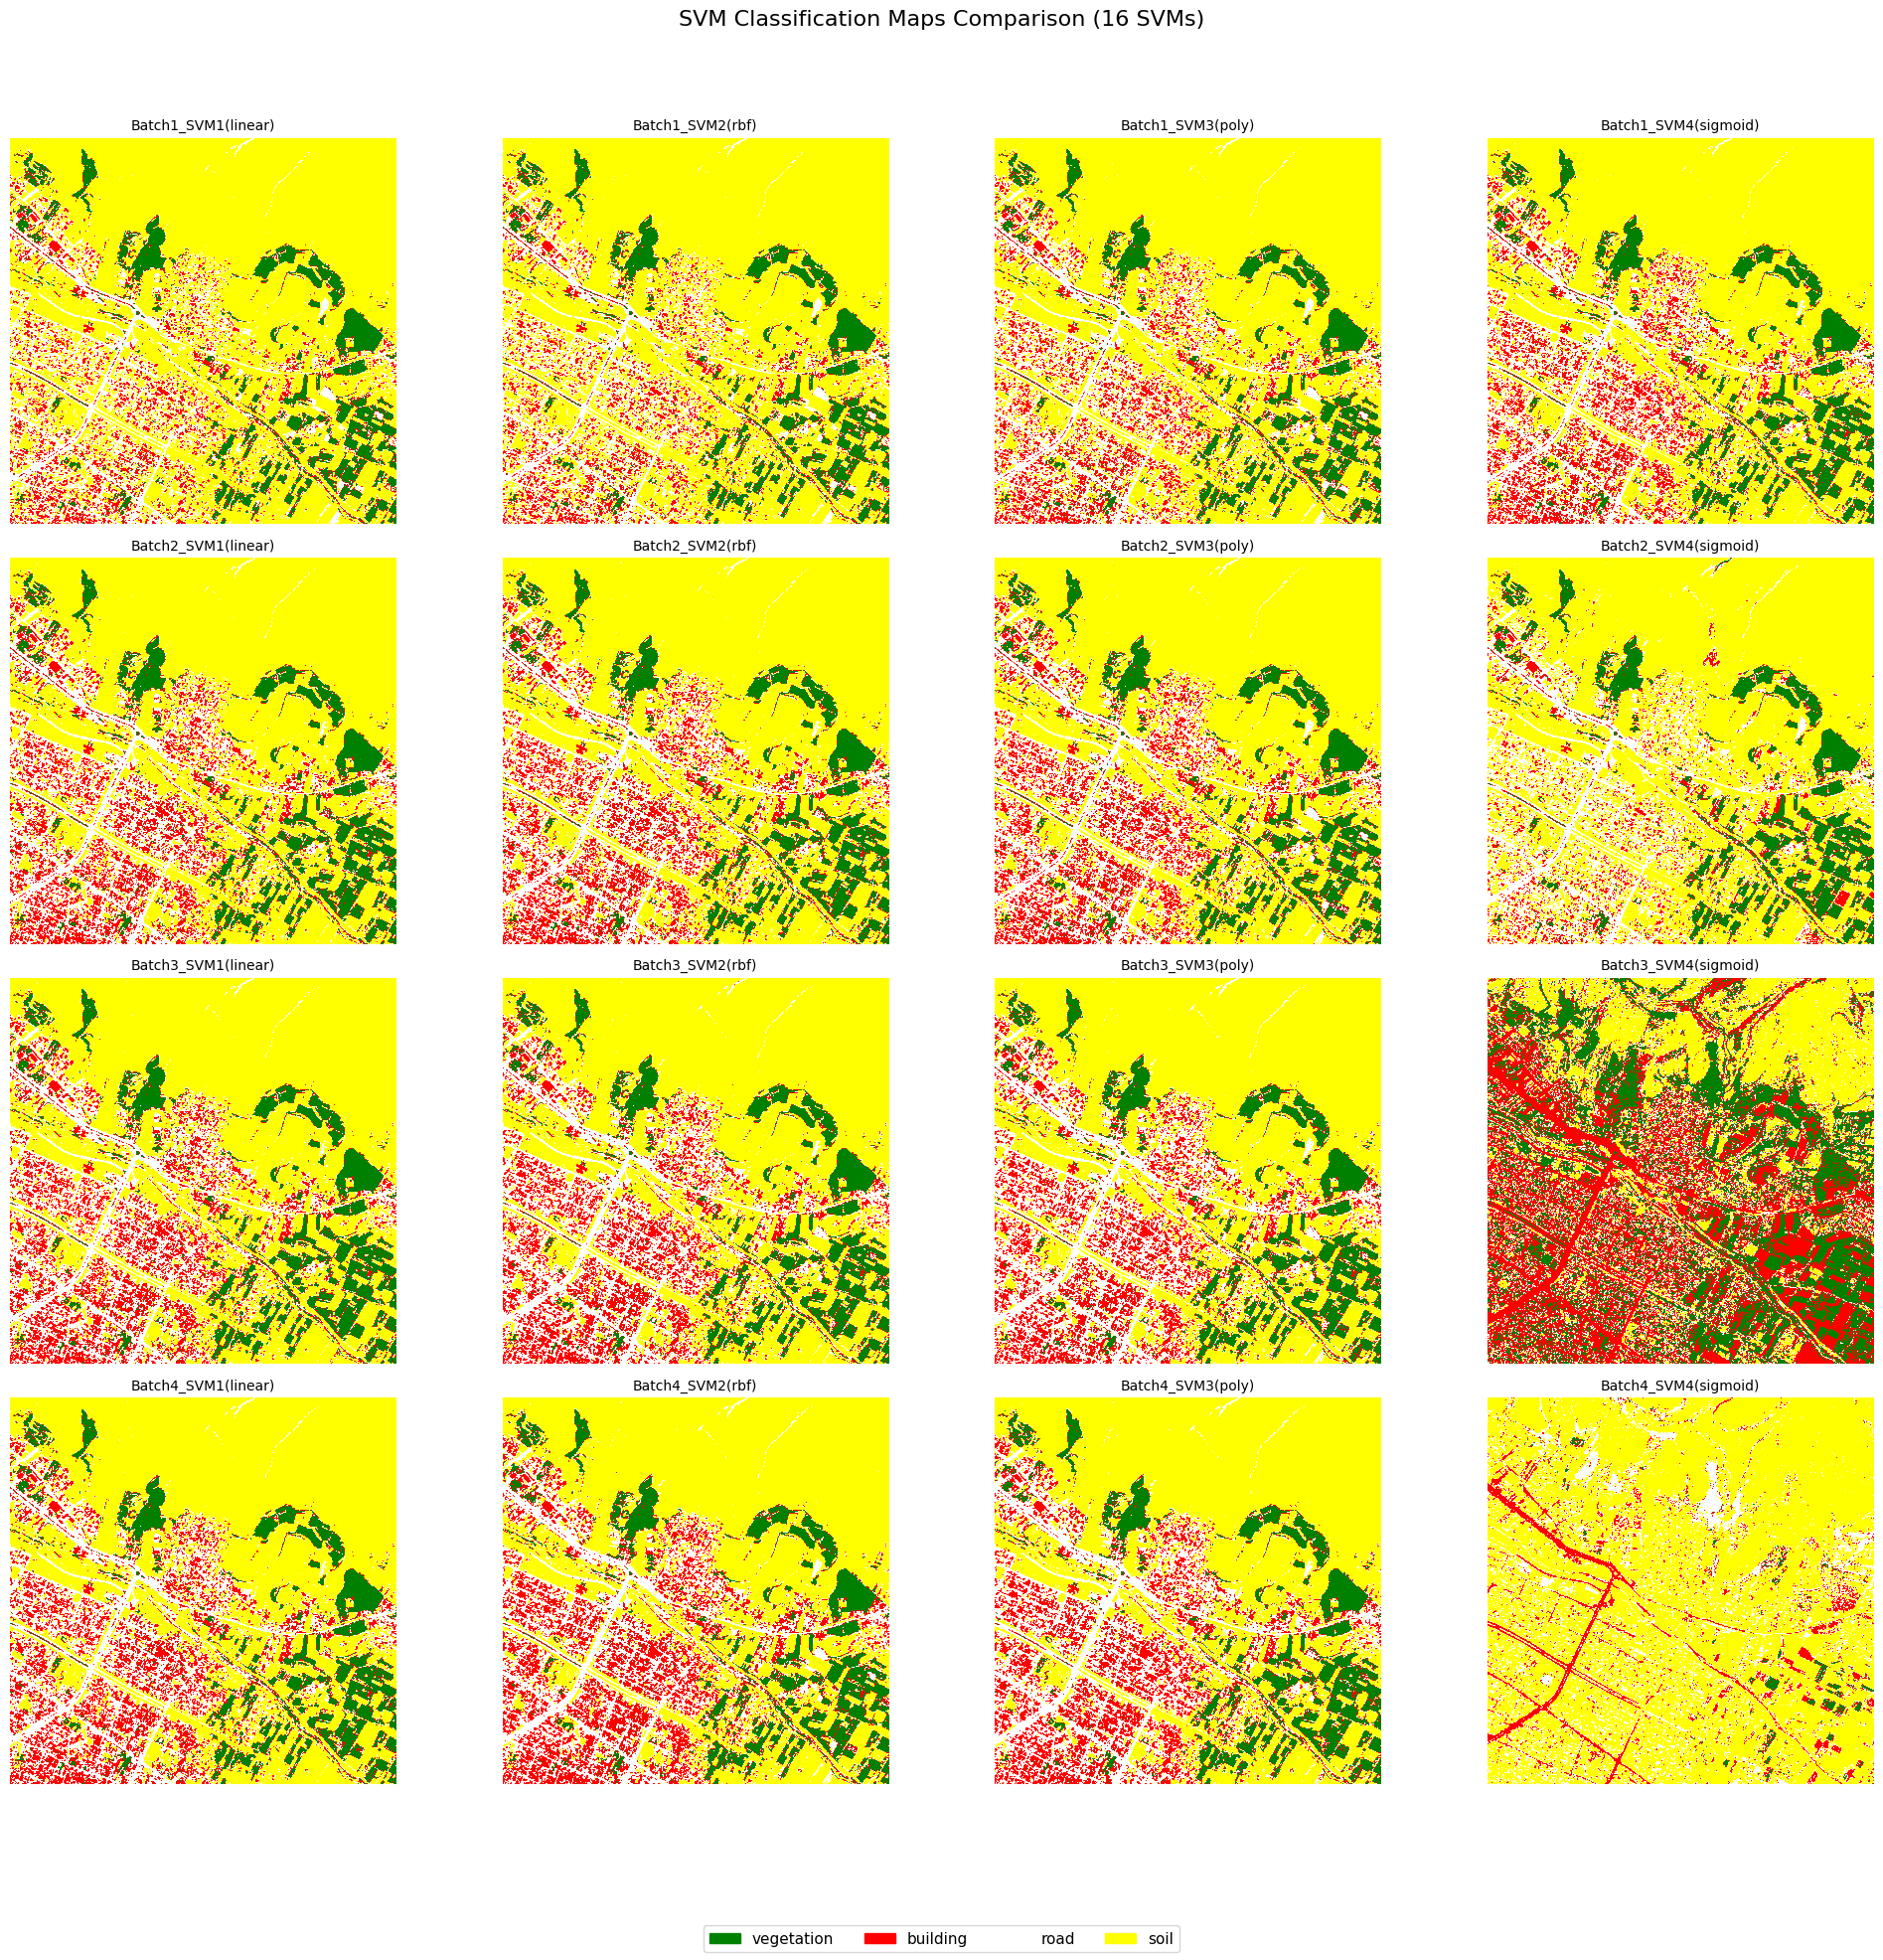

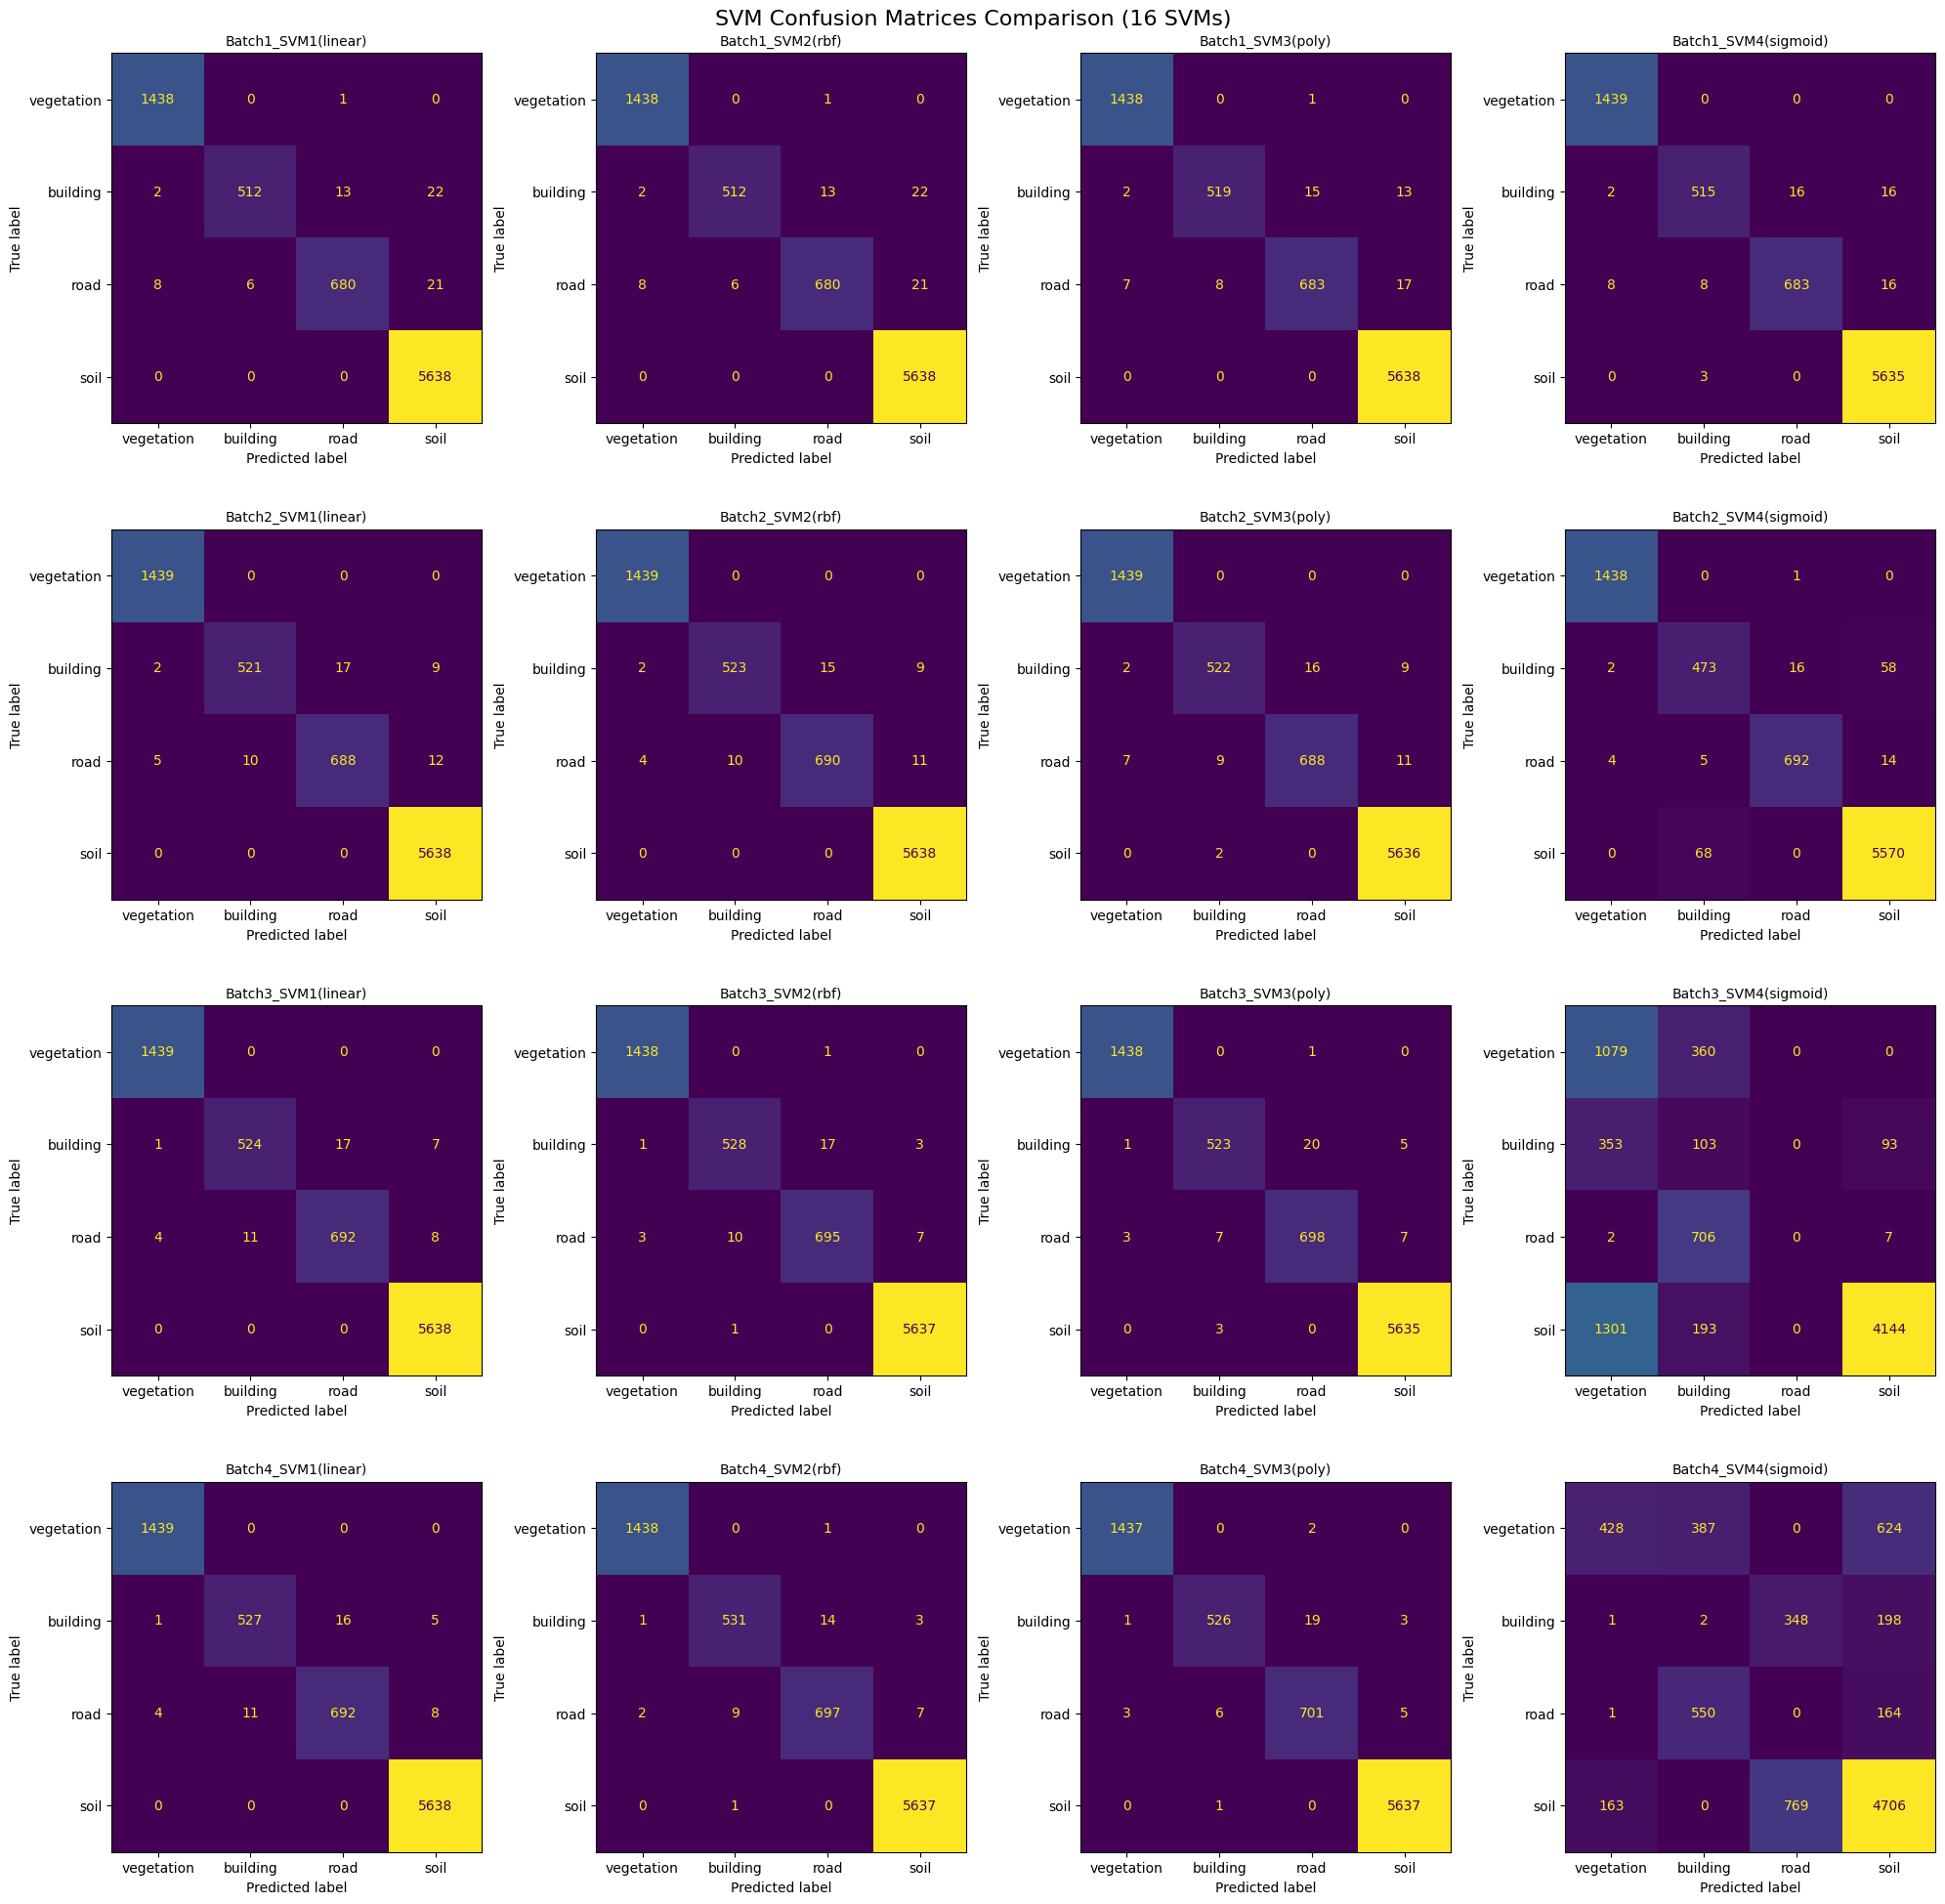


================ SVM Overall Accuracy (16 SVMs) ================
Batch1_SVM1(linear) → 99.12%
Batch1_SVM2(rbf) → 99.12%
Batch1_SVM3(poly) → 99.24%
Batch1_SVM4(sigmoid) → 99.17%
Batch2_SVM1(linear) → 99.34%
Batch2_SVM2(rbf) → 99.39%
Batch2_SVM3(poly) → 99.33%
Batch2_SVM4(sigmoid) → 97.99%
Batch3_SVM1(linear) → 99.42%
Batch3_SVM2(rbf) → 99.48%
Batch3_SVM3(poly) → 99.44%
Batch3_SVM4(sigmoid) → 63.85%
Batch4_SVM1(linear) → 99.46%
Batch4_SVM2(rbf) → 99.54%
Batch4_SVM3(poly) → 99.52%
Batch4_SVM4(sigmoid) → 61.58%


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from skimage.io import imread
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ====================
# NORMALIZATION
# ====================
def normalize(img):
    img = img.astype(np.float32)
    img_min = np.min(img, axis=(0, 1), keepdims=True)
    img_max = np.max(img, axis=(0, 1), keepdims=True)
    return (img - img_min) / (img_max - img_min + 1e-8)

# ====================
# DATA PREPARATION
# ====================
def prepare_data(image_path, roi_path):
    ms = imread(image_path)
    labels = imread(roi_path)

    if len(ms.shape) == 3 and ms.shape[0] < ms.shape[1]:
        ms = np.transpose(ms, (1, 2, 0))

    row, col, band = ms.shape

    if labels.shape != (row, col):
        raise ValueError("ابعاد تصویر و ROI یکسان نیست")

    ms_n = normalize(ms)
    ms_flat = ms_n.reshape(-1, band)
    labels_flat = labels.reshape(-1)

    mask = labels_flat != 0
    X = ms_flat[mask]
    y = labels_flat[mask]

    return X, y, ms_flat, row, col

# ====================
# TRAIN & EVALUATE
# ====================
def train_evaluate(X, y, ms_flat, row, col, model):
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    model.fit(x_train, y_train)

    y_pred_test = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred_test)

    overall_acc = np.sum(cm.diagonal()) / np.sum(cm) * 100

    y_pred_full = model.predict(ms_flat)
    classified_map = y_pred_full.reshape(row, col)

    return cm, overall_acc, classified_map

# ====================
# FILE PATHS
# ====================
image_path = r"D:\UNI\ZNU\Term 1\Pattern Recognition\EXE\saem project\ex1\Step 1\data\BGRNIR.tif"
roi_path = r"D:\UNI\ZNU\Term 1\Pattern Recognition\EXE\saem project\ex1\Step 1\data\rois.tif"

# ====================
# VISUALIZATION SETUP
# ====================
colors = ['green', 'red', 'white', 'yellow']
class_names = ['vegetation', 'building', 'road', 'soil']
cmap = ListedColormap(colors)
legend_patches = [Patch(color=c, label=l) for c, l in zip(colors, class_names)]

# ====================
# SVM SETTINGS: 4 batch مختلف
# ====================
svm_settings_list = [
    # Batch 1
    [
        {"C": 1, "kernel": "linear"},
        {"C": 5, "kernel": "rbf", "gamma": 0.1},
        {"C": 10, "kernel": "poly", "degree": 2, "gamma": 0.5},
        {"C": 15, "kernel": "sigmoid", "gamma": 0.3}
    ],
    # Batch 2
    [
        {"C": 10, "kernel": "linear"},
        {"C": 10, "kernel": "rbf", "gamma": 1},
        {"C": 20, "kernel": "poly", "degree": 3, "gamma": 1},
        {"C": 20, "kernel": "sigmoid", "gamma": 1}
    ],
    # Batch 3
    [
        {"C": 30, "kernel": "linear"},
        {"C": 30, "kernel": "rbf", "gamma": 5},
        {"C": 30, "kernel": "poly", "degree": 3, "gamma": 5},
        {"C": 30, "kernel": "sigmoid", "gamma": 5}
    ],
    # Batch 4
    [
        {"C": 50, "kernel": "linear"},
        {"C": 50, "kernel": "rbf", "gamma": 20},
        {"C": 50, "kernel": "poly", "degree": 4, "gamma": 20},
        {"C": 50, "kernel": "sigmoid", "gamma": 20}
    ]
]

# ====================
# MAIN PROCESS
# ====================
X, y, ms_flat, row, col = prepare_data(image_path, roi_path)

all_svm_maps = {}
all_svm_cms = {}
all_accuracy_table = []

for batch_num, svm_settings in enumerate(svm_settings_list, 1):
    for i, params in enumerate(svm_settings):
        kernel = params.get("kernel", "rbf")
        C = params.get("C", 1)
        gamma = params.get("gamma", "scale")
        degree = params.get("degree", 3)

        print(f"\nTraining Batch {batch_num} - SVM {i+1}: kernel={kernel}, C={C}, gamma={gamma}, degree={degree}")
        model = svm.SVC(C=C, kernel=kernel, gamma=gamma, degree=degree)
        cm, oa, svm_map = train_evaluate(X, y, ms_flat, row, col, model)

        name = f"Batch{batch_num}_SVM{i+1}({kernel})"
        all_svm_maps[name] = svm_map
        all_svm_cms[name] = cm
        all_accuracy_table.append([name, oa])

# ====================
# SUBPLOT: CLASSIFICATION MAPS
# ====================
n_maps = len(all_svm_maps)
cols = 4
rows = (n_maps + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.ravel()

for ax, (name, map_) in zip(axes, all_svm_maps.items()):
    ax.imshow(map_, cmap=cmap)
    ax.set_title(name, fontsize=10)
    ax.axis('off')

# خاموش کردن subplotهای اضافی اگر کمتر از n_maps باشد
for ax in axes[n_maps:]:
    ax.axis('off')

fig.legend(handles=legend_patches, loc="lower center", ncol=len(class_names), fontsize=11, frameon=True)
plt.suptitle("SVM Classification Maps Comparison (16 SVMs)", fontsize=16)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

# ====================
# SUBPLOT: CONFUSION MATRICES
# ====================
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.ravel()

for ax, (name, cm) in zip(axes, all_svm_cms.items()):
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)

# خاموش کردن subplotهای اضافی
for ax in axes[n_maps:]:
    ax.axis('off')

plt.suptitle("SVM Confusion Matrices Comparison (16 SVMs)", fontsize=16)
plt.tight_layout()
plt.show()

# ====================
# PRINT ACCURACY TABLE
# ====================
print("\n================ SVM Overall Accuracy (16 SVMs) ================")
for name, oa in all_accuracy_table:
    print(f"{name} → {oa:.2f}%")
print("=====================================================")
